In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

def list_to_str(list_name):
    string = " + ".join(list_name)
    return string

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

def bayesian_model_standardized(data, target_var_name, cov_list):

    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data_cleaned = remove_nulls_simple(data, cov_list_target_var)
    
    sc = StandardScaler()
    data_standardized = sc.fit_transform(data_cleaned)
    data_standardized = pd.DataFrame(data_standardized)
    data_standardized.columns = data_cleaned.columns

    std = data_cleaned.std()
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data_standardized, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data_cleaned[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values

    return model, output, std, resid

def bayesian_model_unstandardized(data, target_var_name, cov_names):

    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_names} + year",
                      f"sigma ~ {cov_names} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    
    return model, output, resid


In [29]:
cov_set_1 = ['dtr_annual', 'tmean_spring', 'tmean_fall']
cov_set_2 = ['dtr_spring', 'tmean_spring', 'prcp_spring_mm']

In [34]:
gsl_model_1, gsl_output_1, gsl_std_1, gsl_resid_1 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_1)
gsl_model_2, gsl_output_2, gsl_std_2, gsl_resid_2 = bayesian_model_standardized(pa_gs, 'growing_season_length', cov_set_2)
lsf_model_1, lsf_output_1, lsf_std_1, lsf_resid_1 = bayesian_model_standardized(pa_gs, 'last_spring_frost_doy', cov_set_1)
lsf_model_2, lsf_output_2, lsf_std_2, lsf_resid_2 = bayesian_model_standardized(pa_gs, 'last_spring_frost_doy', cov_set_2)
fff_model_1, fff_output_1, fff_std_1, fff_resid_1 = bayesian_model_standardized(pa_gs, 'first_fall_frost_doy', cov_set_1)
fff_model_2, fff_output_2, fff_std_2, fff_resid_2 = bayesian_model_standardized(pa_gs, 'first_fall_frost_doy', cov_set_2)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.850       7           1402.99 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.706       7           1452.25 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.809       7           1363.59 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.845       7           1394.64 draws/s      0:00:01    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [36]:
az.compare({"GSL Model 1":gsl_output_1, "LSF Model 1":lsf_output_1, "FFF Model 1":fff_output_1})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
GSL Model 1,0,0.0,0.0,NaN,,,14.1,-5500.0,77.0,0.80
FFF Model 1,1,-1100.0,77.0,1.0,,,21.4,-6600.0,110.0,0.11
LSF Model 1,2,-1100.0,73.0,1.0,,,11.4,-6700.0,62.0,0.09


In [37]:
az.compare({"GSL Model 2":gsl_output_2, "LSF Model 2":lsf_output_2, "FFF Model 2":fff_output_2})

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
GSL Model 2,0,0.0,0.0,NaN,,,13.2,-6300.0,73.0,0.67
LSF Model 2,1,-400.0,69.0,1.0,,,10.8,-6700.0,62.0,0.28
FFF Model 2,2,-1200.0,65.0,1.0,,,18.7,-7500.0,100.0,0.05


In [61]:
def calculated_v_empirical_std(data, cov_list, target_var_name, model, output):

    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data_cleaned = remove_nulls_simple(data, cov_list_target_var)
    
    resids = data_cleaned['growing_season_length'].values - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    data_cleaned['resids'] = resids
    
    # compute predictions over chains/draws
    model.predict(output, kind="response_params") 
    # average over draws and then add to the data frame
    sigma_hats = output.posterior["sigma"].mean(("chain", "draw")).values  
    data_cleaned["sigma_hat"] = sigma_hats
    # aggregate by year
    sig_by_year = data_cleaned.groupby("year")["sigma_hat"].mean()
    # to get the empirical stds:
    empirical_stds_yearly  = data_cleaned.groupby("year")["resids"].std()
    fig, axs = plt.subplots(1,2, figsize=(8,4))
    axs[0].plot(sig_by_year, label = 'Bayesian Est. Uncertainty')
    axs[1].plot(empirical_stds_yearly, label = 'Yearly Model Residual STD')
    axs[0].legend()
    axs[1].legend()
    plt.show()

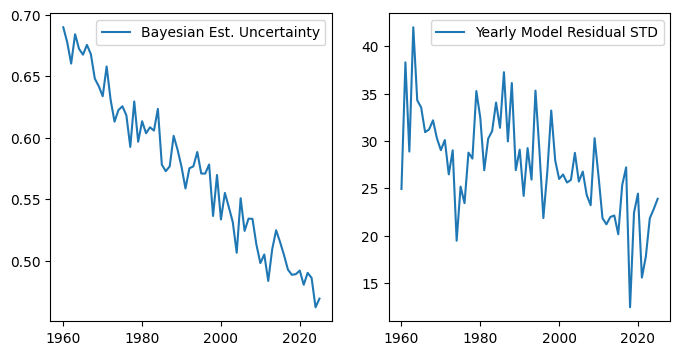

In [62]:
calculated_v_empirical_std(pa_gs, cov_set_1, 'growing_season_length', gsl_model_1, gsl_output_1)

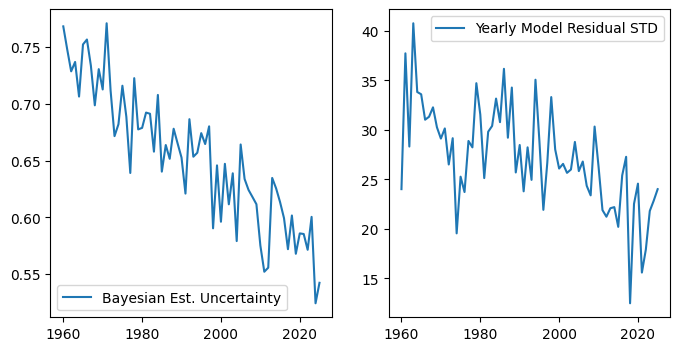

In [63]:
calculated_v_empirical_std(pa_gs, cov_set_2, 'growing_season_length', gsl_model_2, gsl_output_2)